# Tutorial 00: Introduction and Installation

## Overview

An introduction to FitTeD (**Fit**ting **T**ransi**e**nts with **D**iscs), a Python
package for fitting light curves and spectra of astronomical transients with evolving
relativistic accretion discs. This tutorial covers installation, dependencies, and a
first check that everything works.

## Learning Objectives

By the end of this tutorial, you will:

- Understand what FitTeD does
- Have it installed, with its optional components
- Have verified the installation
- Know where to go next

## What is FitTeD?

At its heart FitTeD solves the time-dependent general relativistic disc equations and
turns the resulting temperature profile into multi-band light curves and spectra. All
the relevant relativistic optics is included: Doppler shifting, gravitational energy
shifting, and gravitational lensing.

### Key features

- **Time-dependent disc evolution** from self-consistent solutions of the relativistic
  disc equations
- **Multi-wavelength modelling** of UV/optical and X-ray light curves together
- **Relativistic ray tracing** for the photon transport
- **MCMC fitting** with emcee, parallelised across walkers
- **Flexible data input**: manyTDE, observer-frame fluxes, AB magnitudes, X-ray fluxes,
  with automatic cosmological conversions

### What it is used for

- **Tidal disruption events**: the late-time optical/UV and X-ray emission
- **X-ray binaries**: soft-state light curve decays
- **Luminous fast blue optical transients**

## Citation

If you use FitTeD, please cite:

**Mummery et al. (2025)**, *Fitting transients with discs (FitTeD): a public light
curve and spectral fitting package based on evolving relativistic discs*,
MNRAS **544**, 2225.
[arXiv:2408.15048](https://arxiv.org/abs/2408.15048) ·
[ADS](https://ui.adsabs.harvard.edu/abs/2025MNRAS.544.2225M/abstract)

`cite_fitted.bib` in the repository root has the BibTeX entry.

## Installation

### Step 1: get the package

```bash
git clone https://github.com/fittingtransientswithdiscs/FitTeD.git
cd FitTeD
```

### Step 2: install it

```bash
python3 -m pip install -e .
```

The `-e` (editable) flag is recommended: it lets you edit the package in place and see
the change without reinstalling. A plain `pip install .` works identically.

There is no build step. FitTeD is pure Python, so there is no compiler to install and
nothing to compile — the same install works on Linux, macOS and Windows.

### Step 3: manyTDE (optional, recommended)

To load TDE photometry by IAU name — `Data_Set(manyTDE_name='AT2019dsg', ...)` —
install manyTDE:

```bash
git clone https://github.com/sjoertvv/manyTDE.git
cd manyTDE
python3 -m pip install -e .
```

Only Tutorial 06 requires it. Everything else uses data that ships with FitTeD or that
you supply yourself.

## Dependencies

Installed automatically by pip:

| Package | Used for |
|---------|----------|
| numpy | everything |
| scipy | special functions, optimisation |
| astropy | cosmology, units, constants |
| matplotlib | plotting |
| emcee | MCMC sampling |
| corner | corner plots |
| h5py | HDF5 chain backends |
| numba | the compiled Bessel-function kernels |
| pandas, tqdm, importlib_resources | data handling and progress bars |

Optional: **manyTDE**, which lets you load published photometry by IAU name. It is the
only optional dependency, and only Tutorial 06 uses it.

### Python version

FitTeD is developed and tested on **Python 3.10 and newer**.

## Verifying the installation

The cell below imports the package. FitTeD prints a banner on import that reports the
version and whether it found manyTDE.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# If FitTeD was installed with `pip install -e .` this block is unnecessary.
# It is here so the notebooks also work from a bare checkout.
package_dir = Path().resolve().parent
if str(package_dir) not in sys.path:
    sys.path.append(str(package_dir))   # append, so an installed copy wins

import fitted
fitted.format_plots()

print("FitTeD version:", fitted.__version__)

No module named 'manyTDE'


/tmp/ipykernel_6597/1659882622.py:13: UserWarning: manyTDE is not avaliable, please install it.  (https://github.com/sjoertvv/manyTDE)
  import fitted



  _____  _  _   _____      ____   
 |  ___|(_)| |_|_   _|___ |  _ \  
 | |_   | || __| | | / _ \| | | | 
 |  _|  | || |_  | ||  __/| |_| | 
 |_|    |_| \__| |_| \___||____/  
                                  
   FITing TransiEnts with Discs   

 Version 2.0.0
 manyTDE compatible?  No

 FitTeD was created by Andrew Mummery* and Edward Nathan$.

 Please cite us if you make use of this code
 https://ui.adsabs.harvard.edu/abs/2025MNRAS.544.2225M/abstract

 * amummery@ias.edu
 $ edward.j.r.nathan@gmail.com




FitTeD version: 2.0.0


In [2]:
print("manyTDE available: ", fitted.data.manyTDE_available)
print()
print("manyTDE is required for Tutorial 06 and nothing else.")
print("'No' here is a perfectly good installation.")

manyTDE available:  No

manyTDE is required for Tutorial 06 and nothing else.
'No' here is a perfectly good installation.


## A first model

Three objects, in the order you will always build them: a `Data_Set`, a model, and a
`Fit` that ties them together with a prior.

In [3]:
data = fitted.data.Data_Set()        # empty, just to show the shape of things

model = fitted.models.GR_disc(
    data=data,
    decay=True,
    decay_type='pl',
    rise=False,
)

fit = fitted.Fit(model=model)

print("Data_Set: %d UV/optical bands, %d X-ray bands"
      % (len(data.bands_UV), len(data.bands_X)))
print("Model:    %d key + %d early-time parameters"
      % (len(model.default_key_pars), len(model.default_early_pars)))
print("Fit:      ready")

Data_Set: 0 UV/optical bands, 0 X-ray bands
Model:    7 key + 4 early-time parameters
Fit:      ready


## Does it actually compute something?

A quick end-to-end check: evaluate a disc light curve in the optical and the X-ray.
If this cell produces a plot, the installation works.

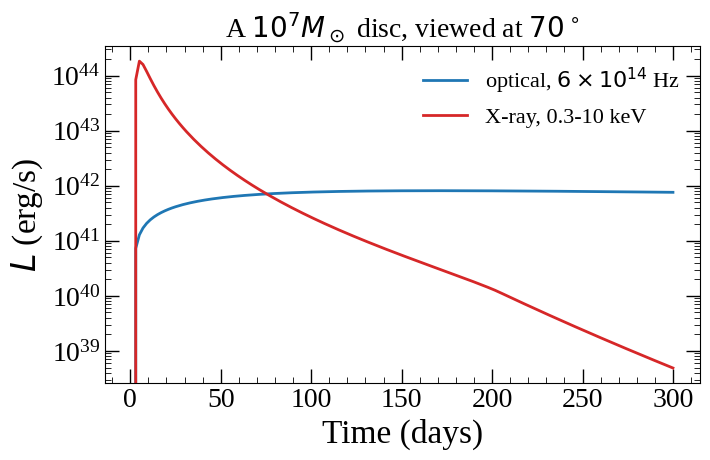

If you see two curves above, FitTeD is working.


In [4]:
times = np.linspace(1, 300, 150)                 # days
log_mh, a_bh, m_disc, r0, tvi, t0, incl = 7.0, 0.01, 0.05, 30.0, 15.0, -2.0, 70.0

lum_uv = model.model_UV(times, log_mh, a_bh, m_disc, r0, tvi, t0, incl, v=6.0e14)
lum_x = model.model_X(times, log_mh, a_bh, m_disc, r0, tvi, t0, incl, El=0.3, Eh=10.0)

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(times, lum_uv, 'C0-', lw=2, label=r'optical, $6\times10^{14}$ Hz')
ax.plot(times, lum_x, 'C3-', lw=2, label='X-ray, 0.3-10 keV')
ax.set(xlabel='Time (days)', ylabel=r'$L$ (erg/s)', yscale='log',
       title=r'A $10^7 M_\odot$ disc, viewed at $70^\circ$')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print("If you see two curves above, FitTeD is working.")

The two bands behave completely differently, and that is the whole reason for fitting
them together. The optical sits on the Rayleigh–Jeans tail of the disc spectrum and
declines gently; the X-ray sits on the Wien tail and is exponentially sensitive to the
inner-disc temperature, so it falls by orders of magnitude over the same window. The
X-rays are where the black hole mass information is.

## Where next

| Tutorial | What it covers | Needs manyTDE? |
|----------|----------------|----------------|
| 01 | Loading and cleaning data | no |
| 02 | Observer-frame input and cosmological conversions | no |
| 03 | Model parameters, and physical vs sampled variables | no |
| 04 | Fitting: priors, optimisation, and its limits | no |
| 05 | MCMC with emcee, and how to tell if it converged | no |
| 09 | Accuracy and performance options, measured | no |
| 10 | The whole workflow on AT2019dsg | **yes** |

Read 03 before 04 even if you are in a hurry. It explains the difference between the
parameters the physics uses and the parameters the sampler moves, which is the single
most common source of confusion with this package.

## Getting help

- The paper: [arXiv:2408.15048](https://arxiv.org/pdf/2408.15048)
- Example scripts: `fitted/examples/`
- `model.what_pars()` prints what any model instance expects, in order
- Repository: [Bitbucket](https://bitbucket.org/fittingtransientswithdiscs/fitted_public/src/main/)